# Lab 5 — De la anomalía a la prescripción
**Módulo 5 · Clase 5 — Detección de anomalías agronómicas**

Cerramos el bucle: detectamos lo **anómalo** y lo convertimos en un **mapa de prescripción** auditable. Quinto commit — y el corazón del proyecto integrador.

### Qué vas a hacer
1. Cargar los índices de la parcela (NDVI/NDRE/NDWI del Lab 3).
2. Detectar anomalías de **dos formas**: z-score (residuo) e **Isolation Forest** (no supervisado).
3. Segmentar zonas de actuación y generar un **mapa de prescripción** (3 dosis).
4. Aplicar una **capa de reglas expertas** (umbral + restricción legal + ventana fenológica).
5. Exportar el mapa en formato cargable y documentar las reglas.

> Postura del módulo: la anomalía **localiza y prioriza**; **no** diagnostica la causa. La salida del modelo **nunca** se aplica cruda: pasa por las reglas.


In [ ]:
pip install -q rioxarray xarray numpy scikit-learn matplotlib


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 72.0/72.0 kB 2.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 31.4 MB/s eta 0:00:00


In [ ]:
import os
import numpy as np, matplotlib.pyplot as plt
import rioxarray as rxr

# Entrada: los índices que guardó el Lab 3 (ndvi.tif, ndre.tif, ndwi.tif).
# El Lab 3 los generó leyendo Sentinel-2 L2A del bucket público de AWS
# (earth-search / Element84, acceso anónimo, SIN login). Este lab NO vuelve a
# descargar nada: trabaja sobre esos rásters. Si te faltan, re-ejecuta el Lab 3
# (AWS) y copia los .tif a esta carpeta.
def load(name): return rxr.open_rasterio(f"{name}.tif").squeeze().values.astype("float32")

if all(os.path.exists(f"{n}.tif") for n in ("ndvi","ndre","ndwi")):
    NDVI, NDRE, NDWI = load("ndvi"), load("ndre"), load("ndwi")
    print("Índices del Lab 3 cargados (origen AWS):", NDVI.shape)
else:
    print("No encuentro ndvi/ndre/ndwi.tif del Lab 3. Re-ejecútalo (AWS) para los datos reales.")
    print("-> Genero un mosaico SINTÉTICO solo para ver el flujo de detección y prescripción.")
    rng=np.random.default_rng(42); H=W=120
    base=np.clip(0.6+0.15*np.sin(np.linspace(0,3,W))[None,:]+rng.normal(0,0.05,(H,W)),0,1)
    base[20:40,70:95]-=0.35   # una zona anómala de bajo vigor (para que el detector tenga algo que marcar)
    NDVI=base.astype("float32")
    NDRE=np.clip(NDVI*0.6+rng.normal(0,0.03,(H,W)),0,1).astype("float32")
    NDWI=np.clip(0.1+0.2*NDVI+rng.normal(0,0.04,(H,W)),-0.2,0.6).astype("float32")
print("Shapes:", NDVI.shape, NDRE.shape, NDWI.shape)

Índices del Lab 3 cargados (origen AWS): (2254, 1709)
Shapes: (2254, 1709) (2254, 1709) (2254, 1709)


## 1. Anomalía por z-score (residuo frente a lo esperado)
Marcamos como anómalo cada píxel cuyo NDVI se desvía más de **k·σ** de la mediana de la parcela. Es simple e interpretable: detecta zonas claramente por debajo de su entorno.


Píxeles anómalos por z-score: 13.9%


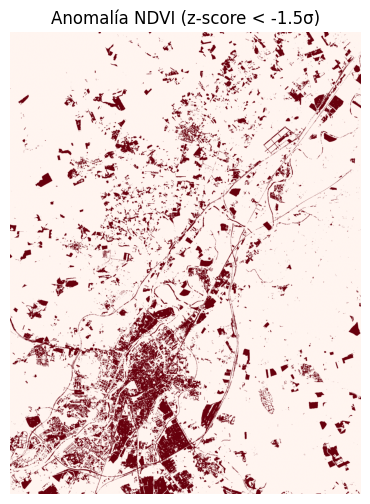

In [ ]:
def zscore_anom(arr, k=1.5):
    med=np.nanmedian(arr); sd=np.nanstd(arr)
    z=(arr-med)/(sd if sd>0 else 1)
    return z, (z < -k)   # anómalo = bajo respecto al resto

z, anom_z = zscore_anom(NDVI, k=1.5)
print(f"Píxeles anómalos por z-score: {100*np.nanmean(anom_z):.1f}%")
plt.figure(figsize=(6,6)); plt.imshow(anom_z, cmap="Reds"); plt.title("Anomalía NDVI (z-score < -1.5σ)"); plt.axis("off"); plt.show()


## 2. Anomalía no supervisada (Isolation Forest)
Sobre un vector de features por píxel (NDVI, NDRE, NDWI) entrenamos un **Isolation Forest** que marca los píxeles "raros" sin etiquetas. Es el patrón reutilizado del proyecto interno BP003.


Píxeles anómalos por Isolation Forest: 10.0%


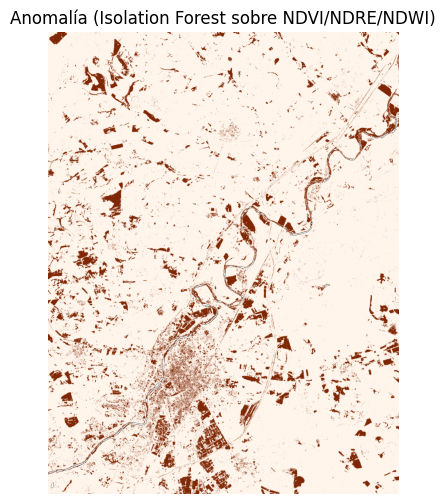

In [ ]:
from sklearn.ensemble import IsolationForest

H,W = NDVI.shape
feats = np.stack([NDVI, NDRE, NDWI], axis=-1).reshape(-1,3)
mask = ~np.isnan(feats).any(axis=1)
X = feats[mask]

iso = IsolationForest(contamination=0.10, random_state=42)
pred = iso.fit_predict(X)              # -1 = anómalo, 1 = normal
anom_if = np.full(H*W, np.nan); anom_if[mask] = (pred==-1).astype(float)
anom_if = anom_if.reshape(H,W)
print(f"Píxeles anómalos por Isolation Forest: {100*np.nanmean(anom_if==1):.1f}%")
plt.figure(figsize=(6,6)); plt.imshow(anom_if, cmap="Oranges"); plt.title("Anomalía (Isolation Forest sobre NDVI/NDRE/NDWI)"); plt.axis("off"); plt.show()


## 3. Zonas de actuación → mapa de prescripción
Segmentamos por vigor (terciles de NDVI) en 3 zonas y asignamos una dosis base. **Idea agronómica:** a menor vigor, más aporte (dentro de límites). Esto es el mapa de variabilidad → prescripción del flujo VRT.


In [ ]:
q1,q2=np.nanpercentile(NDVI,[33,66])
zona=np.full(NDVI.shape,np.nan)
zona[NDVI<=q1]=0; zona[(NDVI>q1)&(NDVI<=q2)]=1; zona[NDVI>q2]=2   # 0 bajo,1 medio,2 alto

# Dosis base de N (kg/ha) por zona (más a la zona de menor vigor)
DOSIS_BASE = {0:120, 1:90, 2:60}
prescripcion = np.full(NDVI.shape, np.nan)
for zid,dosis in DOSIS_BASE.items():
    prescripcion[zona==zid] = dosis


## 4. Capa de reglas expertas (lo que hace auditable la recomendación)
La dosis base **no se aplica cruda**. Pasa por reglas: límite legal, ventana fenológica y seguridad. Cada regla queda registrada.


In [ ]:
reglas_aplicadas=[]

# Regla 1 — Límite legal de N (ej. zona vulnerable a nitratos): tope 110 kg/ha
LIMITE_LEGAL_N = 110
topado = prescripcion > LIMITE_LEGAL_N
prescripcion = np.minimum(prescripcion, LIMITE_LEGAL_N)
reglas_aplicadas.append(f"Límite legal N {LIMITE_LEGAL_N} kg/ha aplicado a {int(np.nansum(topado))} píxeles.")

# Regla 2 — Ventana fenológica: solo fertilizar si el cultivo está en estado vegetativo (flag externo)
EN_VENTANA_FENOLOGICA = True   # se decide con la serie de la Clase 4 (no aplicar en senescencia)
if not EN_VENTANA_FENOLOGICA:
    prescripcion[:] = 0
    reglas_aplicadas.append("Fuera de ventana fenológica: prescripción anulada (0).")
else:
    reglas_aplicadas.append("Dentro de ventana fenológica: se permite la aplicación.")

# Regla 3 — Seguridad: en píxeles con estrés hídrico fuerte (NDWI muy bajo) no fertilizar (primero regar)
estres_hidrico = NDWI < np.nanpercentile(NDWI,10)
prescripcion[estres_hidrico] = 0
reglas_aplicadas.append(f"Estrés hídrico (NDWI<P10): prescripción a 0 en {int(np.nansum(estres_hidrico))} píxeles (regar antes de fertilizar).")

print("Reglas aplicadas:")
for r in reglas_aplicadas: print(" -", r)


Reglas aplicadas:
 - Límite legal N 110 kg/ha aplicado a 1267751 píxeles.
 - Dentro de ventana fenológica: se permite la aplicación.
 - Estrés hídrico (NDWI<P10): prescripción a 0 en 384166 píxeles (regar antes de fertilizar).


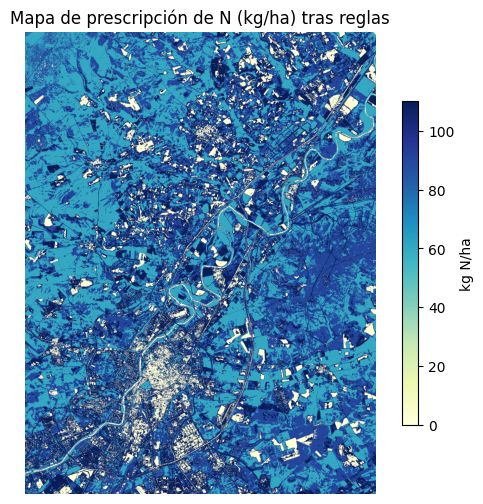

Dosis presentes (kg/ha): [np.float64(0.0), np.float64(60.0), np.float64(90.0), np.float64(110.0)]


In [ ]:
import matplotlib.colors as mcolors
plt.figure(figsize=(7,6))
im=plt.imshow(prescripcion, cmap="YlGnBu")
plt.title("Mapa de prescripción de N (kg/ha) tras reglas"); plt.axis("off"); plt.colorbar(im,shrink=.7,label="kg N/ha")
plt.show()
print("Dosis presentes (kg/ha):", sorted(set(np.unique(prescripcion[~np.isnan(prescripcion)]))))


## 5. Exportar el mapa de prescripción y el registro de reglas


In [ ]:
import os, xarray as xr, rioxarray as rxr
# Plantilla georreferenciada: si existe el ndvi.tif del Lab 3 (AWS) la reutilizamos;
# si trabajamos en modo demo (sintético), creamos una rejilla simple para poder exportar.
if os.path.exists("ndvi.tif"):
    ref=rxr.open_rasterio("ndvi.tif").squeeze()
else:
    h,w=prescripcion.shape
    ref=xr.DataArray(np.zeros((h,w),"float32"),
        coords={"y":np.arange(h)[::-1],"x":np.arange(w)}, dims=("y","x")).rio.write_crs("EPSG:32630")
out=ref.copy(); out.values=prescripcion.astype("float32")
out.rio.to_raster("prescripcion_N.tif")
with open("reglas_aplicadas.md","w") as f:
    f.write("# Reglas aplicadas al mapa de prescripción\n\n")
    f.write(f"Dosis base por zona (kg N/ha): {DOSIS_BASE}\n\n")
    for r in reglas_aplicadas: f.write(f"- {r}\n")
print("Guardados: prescripcion_N.tif + reglas_aplicadas.md")

Guardados: prescripcion_N.tif + reglas_aplicadas.md


## 6. Preguntas para entregar
1. ¿Coinciden las anomalías del z-score y del Isolation Forest? ¿Dónde difieren y por qué?
2. ¿Qué zona recibe más dosis y por qué tiene sentido agronómico?
3. ¿Qué reglas modificaron la dosis base y cuántos píxeles afectaron? ¿Por qué el híbrido (ML + reglas) es preferible al modelo solo?
4. Antes de aplicar este mapa en campo, ¿qué verificarías primero (postura del módulo)?

**Entrega:** `prescripcion_N.tif` + `reglas_aplicadas.md` + justificación agronómica. **Quinto commit.** Antes de la Clase 6 (30/06).
